# Images as tensors

**Learning objective:** Read grayscale image batches and understand height, width and channel axes.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:15:21.868648: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974921.884876    3725 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974921.889365    3725 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:15:23.556647: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
(x_train,y_train),_=tf.keras.datasets.fashion_mnist.load_data()
names=["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
print("raw image batch:",x_train.shape,"labels:",y_train.shape,"dtype:",x_train.dtype,"range:",(x_train.min(),x_train.max()))
x=x_train[:8,...,None]
print("CNN-ready batch:",x.shape,"= (batch, height, width, channels)")


    0/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


       0/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  557056/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 4202496/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

...

   0/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


      0/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


raw image batch: (60000, 28, 28) labels: (60000,) dtype: uint8 range: (np.uint8(0), np.uint8(255))
CNN-ready batch: (8, 28, 28, 1) = (batch, height, width, channels)


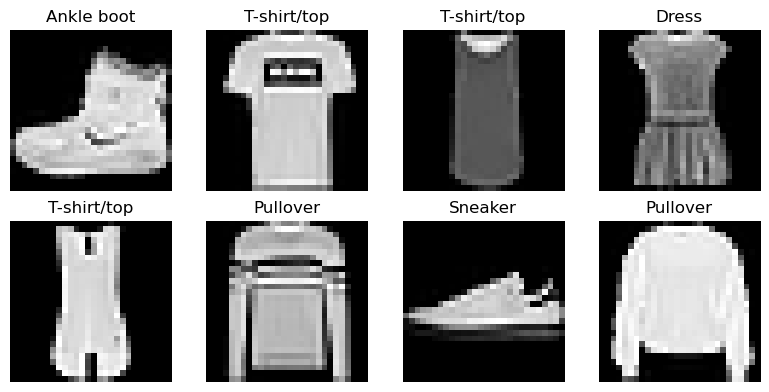

In [3]:
fig,axes=plt.subplots(2,4,figsize=(8,4))
for ax,img,label in zip(axes.flat,x_train[:8],y_train[:8]): ax.imshow(img,cmap="gray"); ax.set_title(names[label]); ax.axis("off")
plt.tight_layout(); plt.show()


For RGB images the last dimension is usually 3. Keras `Conv2D` expects `(batch, height, width, channels)` by default.
